# Pair Proxy Weakness — 100 networks, 100 unseen points

100 nets x 100 unseen x 10 classes = 100,000 LPs. ~16 hours on A100.

**Setup:** A100, High RAM, Run all. Leave overnight.

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, time, json, copy
from torchvision import datasets, transforms
from scipy.stats import spearmanr
from scipy.optimize import linprog

DEVICE = torch.device('cuda')
props = torch.cuda.get_device_properties(0)
mem = getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)
print(f'GPU: {torch.cuda.get_device_name(0)}, {mem/1e9:.0f} GB')
torch.manual_seed(42); np.random.seed(42)

transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.1307,),(0.3081,))])
train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST('./data', train=False, download=True, transform=transform)

X_train_full = train_ds.data.float().view(-1,784).to(DEVICE)/255.0
y_train_full = train_ds.targets.to(DEVICE)
X_test = test_ds.data.float().view(-1,784).to(DEVICE)/255.0
y_test = test_ds.targets.to(DEVICE)

N_CHILD = 250
child_idx = torch.randperm(len(X_train_full),
                           generator=torch.Generator().manual_seed(42))[:N_CHILD]
X_train = X_train_full[child_idx]
y_train = y_train_full[child_idx]

X_pool = torch.cat([X_train_full, X_test])
y_pool = torch.cat([y_train_full, y_test])
unseen_mask = torch.ones(len(X_pool), dtype=torch.bool, device=DEVICE)
unseen_mask[child_idx] = False
X_unseen = X_pool[unseen_mask]
y_unseen = y_pool[unseen_mask]

# Subsample unseen for tractability
N_UNSEEN_SAMPLE = 100
unseen_sub_idx = torch.randperm(len(X_unseen),
    generator=torch.Generator().manual_seed(99))[:N_UNSEEN_SAMPLE]
X_unseen_sub = X_unseen[unseen_sub_idx]
y_unseen_sub = y_unseen[unseen_sub_idx]

print(f'Child: {len(X_train)}, Unseen: {len(X_unseen)}, '
      f'Unseen sample: {N_UNSEEN_SAMPLE}, Test: {len(X_test)}')

GPU: NVIDIA A100-SXM4-80GB, 85 GB


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.72MB/s]


Child: 250, Unseen: 69750, Unseen sample: 100, Test: 10000


In [ ]:
D1, D2 = 64, 8
N_NETS = 100
N_CLASSES = 10
BATCH_SIZE = 64
LR = 0.1
MAX_EPOCHS = 500
MARGIN = 1e-4  # strict inequality margin for LP

class MLP3(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, D1)
        self.fc2 = nn.Linear(D1, D2)
        self.fc3 = nn.Linear(D2, 10)
    def forward(self, x):
        return self.fc3(torch.relu(self.fc2(torch.relu(self.fc1(x)))))

def train_full(seed):
    torch.manual_seed(seed)
    model = MLP3().to(DEVICE)
    opt = optim.SGD(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()
    N = len(X_train)
    for ep in range(MAX_EPOCHS):
        perm = torch.randperm(N, device=DEVICE)
        for s in range(0, N, BATCH_SIZE):
            idx = perm[s:s+BATCH_SIZE]
            loss = loss_fn(model(X_train[idx]), y_train[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        if (ep+1) % 10 == 0:
            with torch.no_grad():
                if (model(X_train).argmax(1)==y_train).float().mean().item() >= 0.9999:
                    break
    return model

@torch.no_grad()
def accuracy(model, X, y):
    model.eval(); a = (model(X).argmax(1)==y).sum().item()/len(X); model.train()
    return a

def hessian_trace(model, n_samples=30):
    loss_fn = nn.CrossEntropyLoss(); model.eval()
    traces = []
    for _ in range(n_samples):
        model.zero_grad()
        grads = torch.autograd.grad(loss_fn(model(X_train), y_train),
                                     model.parameters(), create_graph=True)
        vs = [torch.randint(0,2,p.shape,device=DEVICE).float()*2-1
              for p in model.parameters()]
        gv = sum((g*v).sum() for g,v in zip(grads,vs))
        hvps = torch.autograd.grad(gv, model.parameters())
        traces.append(sum((v*hv).sum().item() for v,hv in zip(vs,hvps)))
    model.train()
    return np.mean(traces)

def apply_T_beta(model, beta):
    m = copy.deepcopy(model)
    with torch.no_grad():
        m.fc1.weight.mul_(beta); m.fc1.bias.mul_(beta)
        m.fc2.weight.mul_(1.0/beta)
    return m

print(f'Architecture: 784 -> {D1} -> {D2} -> 10')
print(f'Layer 3 params: {D2*N_CLASSES + N_CLASSES} '
      f'({D2}x{N_CLASSES} weights + {N_CLASSES} bias)')
print(f'Training constraints per point: {N_CLASSES - 1}')
print(f'Total training constraints: {N_CHILD * (N_CLASSES - 1)}')

Architecture: 784 -> 64 -> 8 -> 10
Layer 3 params: 90 (8x10 weights + 10 bias)
Training constraints per point: 9
Total training constraints: 2250


In [ ]:
######################################################################
# PAIR PROXY VIA LINEAR FEASIBILITY
######################################################################

def build_training_constraints(model):
    """Build the constraint matrix for correct classification of training data.

    Layer 3 computes: logits = W @ h + b, where h is the D2-dim L2 output.
    We flatten [W; b] into a single parameter vector w of length D2*10 + 10 = 90.

    For training point (h_i, y_i), correct classification requires:
      logits[y_i] > logits[c] + margin  for all c != y_i
    i.e.  w^T a_{i,c} >= margin
    where a_{i,c} encodes the difference in feature contributions.

    Returns: A_ub, b_ub for the constraint A_ub @ w <= b_ub
    (scipy convention: inequality is <=, so we negate)
    """
    model.eval()
    with torch.no_grad():
        h1 = torch.relu(model.fc1(X_train))
        H_train = torch.relu(model.fc2(h1)).cpu().numpy()  # (250, D2)
        y_np = y_train.cpu().numpy()

    n_params = D2 * N_CLASSES + N_CLASSES  # 90
    constraints_A = []
    constraints_b = []

    for i in range(N_CHILD):
        h_i = H_train[i]  # (D2,)
        yi = y_np[i]
        for c in range(N_CLASSES):
            if c == yi:
                continue
            # We need: w_yi @ h_i + b_yi - w_c @ h_i - b_c >= margin
            # In terms of flat param vector w = [W_row0, W_row1, ..., b0, b1, ...]
            # W is (10, D2), so W_row_k starts at index k*D2
            # b_k is at index 10*D2 + k

            row = np.zeros(n_params)
            # +h_i for the correct class row
            row[yi*D2 : (yi+1)*D2] = h_i
            # -h_i for the wrong class row
            row[c*D2 : (c+1)*D2] = -h_i
            # +1 for correct class bias
            row[N_CLASSES*D2 + yi] = 1.0
            # -1 for wrong class bias
            row[N_CLASSES*D2 + c] = -1.0

            # We need row @ w >= margin
            # scipy wants A_ub @ w <= b_ub, so negate:
            # -row @ w <= -margin
            constraints_A.append(-row)
            constraints_b.append(-MARGIN)

    return np.array(constraints_A), np.array(constraints_b)


def check_feasibility(A_train, b_train, h_x, target_class):
    """Check if training constraints + 'classify x as target_class' is feasible."""
    n_params = D2 * N_CLASSES + N_CLASSES

    # Additional constraints: score[target_class] > score[c] + margin for all c != target
    extra_A = []
    extra_b = []
    for c in range(N_CLASSES):
        if c == target_class:
            continue
        row = np.zeros(n_params)
        row[target_class*D2 : (target_class+1)*D2] = h_x
        row[c*D2 : (c+1)*D2] = -h_x
        row[N_CLASSES*D2 + target_class] = 1.0
        row[N_CLASSES*D2 + c] = -1.0
        extra_A.append(-row)
        extra_b.append(-MARGIN)

    A_all = np.vstack([A_train, np.array(extra_A)])
    b_all = np.concatenate([b_train, np.array(extra_b)])

    # Feasibility: minimise 0 subject to constraints
    c_obj = np.zeros(n_params)
    try:
        res = linprog(c_obj, A_ub=A_all, b_ub=b_all,
                      bounds=[(None, None)] * len(c_obj),
                      method='highs', options={'presolve': True})
        return res.success and res.status == 0
    except:
        return False


def compute_pair_proxy(model):
    """Compute the pair proxy: count feasible (x, c) pairs for unseen x."""
    # Get L2 representations of unseen subsample
    model.eval()
    with torch.no_grad():
        h1 = torch.relu(model.fc1(X_unseen_sub))
        H_unseen = torch.relu(model.fc2(h1)).cpu().numpy()  # (500, D2)

    # Build training constraints once
    A_train, b_train = build_training_constraints(model)

    # First check: are training constraints themselves feasible?
    c_obj = np.zeros(D2 * N_CLASSES + N_CLASSES)
    res = linprog(c_obj, A_ub=A_train, b_ub=b_train,
                  bounds=[(None, None)] * len(c_obj),
                  method='highs', options={'presolve': True})
    if not (res.success and res.status == 0):
        print('    WARNING: training constraints infeasible!')
        return 0, 0

    # Count feasible pairs
    n_feasible = 0
    n_total = 0

    for j in range(N_UNSEEN_SAMPLE):
        h_x = H_unseen[j]
        for c in range(N_CLASSES):
            n_total += 1
            if check_feasibility(A_train, b_train, h_x, c):
                n_feasible += 1

    return n_feasible, n_total


# Quick sanity check on first network
print('Testing LP setup...')
test_model = train_full(0)
te = accuracy(test_model, X_test, y_test)
tr = accuracy(test_model, X_train, y_train)
print(f'Test model: train={tr:.4f}, test={te:.4f}')

A_t, b_t = build_training_constraints(test_model)
print(f'Constraint matrix: {A_t.shape} (should be ~{N_CHILD*(N_CLASSES-1)} x {D2*N_CLASSES+N_CLASSES})')

# Check a few pairs
test_model.eval()
with torch.no_grad():
    h1 = torch.relu(test_model.fc1(X_unseen_sub[:3]))
    H_test = torch.relu(test_model.fc2(h1)).cpu().numpy()

t0 = time.time()
for j in range(3):
    feasible_classes = []
    for c in range(N_CLASSES):
        if check_feasibility(A_t, b_t, H_test[j], c):
            feasible_classes.append(c)
    true_label = y_unseen_sub[j].item()
    print(f'  Unseen point {j} (true={true_label}): '
          f'feasible classes={feasible_classes} ({len(feasible_classes)}/10)')
dt = time.time() - t0
print(f'  Time for 30 LPs: {dt:.2f}s ({dt/30*1000:.0f}ms each)')
est_total = dt/30 * N_UNSEEN_SAMPLE * N_CLASSES * N_NETS
print(f'  Estimated total time: {est_total/3600:.1f} hours')
del test_model

Testing LP setup...
Test model: train=1.0000, test=0.7508
Constraint matrix: (2250, 90) (should be ~2250 x 90)
  Unseen point 0 (true=5): feasible classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (10/10)
  Unseen point 1 (true=1): feasible classes=[0, 1, 3, 4, 5, 7, 8, 9] (8/10)
  Unseen point 2 (true=1): feasible classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (10/10)
  Time for 30 LPs: 1.92s (64ms each)
  Estimated total time: 1.8 hours


In [ ]:
######################################################################
# PHASE 1: TRAIN ALL NETWORKS
######################################################################
t_global = time.time()
networks = []
print(f'Training {N_NETS} networks...')

for seed in range(N_NETS):
    t0 = time.time()
    model = train_full(seed)
    tr = accuracy(model, X_train, y_train)
    te = accuracy(model, X_test, y_test)
    dt = time.time() - t0

    if (seed+1) % 10 == 0 or seed == 0:
        print(f'  [{seed+1:2d}/{N_NETS}] train={tr:.4f} test={te:.4f} ({dt:.0f}s)')

    networks.append(dict(model=model, seed=seed,
                         train_acc=tr, test_acc=te))

ta_list = [n['test_acc'] for n in networks]
n_ok = sum(1 for n in networks if n['train_acc'] > 0.9999)
print(f'\nDone. Memorised: {n_ok}/{N_NETS}')
print(f'Test acc: {np.mean(ta_list):.4f} +/- {np.std(ta_list):.4f} '
      f'(range {np.min(ta_list):.4f} to {np.max(ta_list):.4f})')

Training 100 networks...
  [ 1/100] train=1.0000 test=0.7508 (0s)
  [10/100] train=1.0000 test=0.7886 (0s)
  [20/100] train=1.0000 test=0.7728 (1s)
  [30/100] train=1.0000 test=0.7864 (1s)
  [40/100] train=1.0000 test=0.7538 (0s)
  [50/100] train=1.0000 test=0.7765 (1s)
  [60/100] train=1.0000 test=0.7568 (0s)
  [70/100] train=1.0000 test=0.7670 (1s)
  [80/100] train=1.0000 test=0.7590 (0s)
  [90/100] train=1.0000 test=0.7681 (0s)
  [100/100] train=1.0000 test=0.7481 (1s)

Done. Memorised: 99/100
Test acc: 0.7625 +/- 0.0173 (range 0.7143 to 0.7978)


In [ ]:
######################################################################
# PHASE 2: COMPUTE PAIR PROXY WEAKNESS
######################################################################
print(f'Computing pair proxy weakness ({N_UNSEEN_SAMPLE} unseen points x '
      f'{N_CLASSES} classes = {N_UNSEEN_SAMPLE*N_CLASSES} LPs per network)...')

for i, net in enumerate(networks):
    t0 = time.time()
    n_feasible, n_total = compute_pair_proxy(net['model'])
    dt = time.time() - t0

    net['pair_proxy'] = n_feasible
    net['pair_proxy_total'] = n_total
    net['pair_proxy_frac'] = n_feasible / n_total if n_total > 0 else 0

    if (i+1) % 5 == 0 or i == 0:
        print(f'  [{i+1:2d}/{N_NETS}] test={net["test_acc"]:.4f} '
              f'weakness={n_feasible}/{n_total} '
              f'({net["pair_proxy_frac"]:.4f}) ({dt:.1f}s)')

Computing pair proxy weakness (100 unseen points x 10 classes = 1000 LPs per network)...
  [ 1/100] test=0.7508 weakness=894/1000 (0.8940) (64.7s)
  [ 5/100] test=0.7832 weakness=909/1000 (0.9090) (56.9s)
  [10/100] test=0.7886 weakness=885/1000 (0.8850) (56.5s)
  [15/100] test=0.7719 weakness=903/1000 (0.9030) (65.9s)
  [20/100] test=0.7728 weakness=848/1000 (0.8480) (59.2s)
  [25/100] test=0.7143 weakness=744/1000 (0.7440) (38.0s)
  [30/100] test=0.7864 weakness=903/1000 (0.9030) (56.4s)
  [35/100] test=0.7771 weakness=961/1000 (0.9610) (67.6s)
  [40/100] test=0.7538 weakness=889/1000 (0.8890) (51.9s)
  [45/100] test=0.7564 weakness=822/1000 (0.8220) (50.8s)
  [50/100] test=0.7765 weakness=940/1000 (0.9400) (55.4s)
  [55/100] test=0.7625 weakness=884/1000 (0.8840) (47.4s)
  [60/100] test=0.7568 weakness=937/1000 (0.9370) (56.8s)
  [65/100] test=0.7285 weakness=812/1000 (0.8120) (45.8s)
  [70/100] test=0.7670 weakness=886/1000 (0.8860) (56.4s)
  [75/100] test=0.7710 weakness=867/1000 

In [ ]:
######################################################################
# PHASE 3: SHARPNESS + SIMPLICITY
######################################################################
print('Computing sharpness and simplicity...')
for i, net in enumerate(networks):
    net['hessian'] = hessian_trace(net['model'], n_samples=30)
    with torch.no_grad():
        net['weight_norm'] = sum(p.norm().item()**2
                                 for p in net['model'].parameters())**0.5
    if (i+1) % 10 == 0:
        print(f'  [{i+1:2d}/{N_NETS}] hess={net["hessian"]:.2f}')
print('Done.')

Computing sharpness and simplicity...
  [10/100] hess=49.67
  [20/100] hess=25.63
  [30/100] hess=17.50
  [40/100] hess=45.42
  [50/100] hess=27.94
  [60/100] hess=36.72
  [70/100] hess=18.77
  [80/100] hess=68.33
  [90/100] hess=57.39
  [100/100] hess=16.44
Done.


In [ ]:
######################################################################
# PHASE 4: REPARAMETERISATION CHECK
######################################################################
print('Reparameterisation check...')
for idx in [0, N_NETS//2, N_NETS-1]:
    net = networks[idx]
    model = net['model']
    mb = apply_T_beta(model, 10.0)

    te_b = accuracy(mb, X_test, y_test)
    ht_b = hessian_trace(mb, n_samples=20)
    nf_b, nt_b = compute_pair_proxy(mb)

    print(f'  Net {idx}: '
          f'test {net["test_acc"]:.4f}->{te_b:.4f}  '
          f'hess {net["hessian"]:.1f}->{ht_b:.1f} '
          f'({ht_b/max(net["hessian"],0.01):.0f}x)  '
          f'weakness {net["pair_proxy"]}->{nf_b}')
    del mb; torch.cuda.empty_cache()

In [ ]:
######################################################################
# THE RESULT
######################################################################
ta = np.array([n['test_acc'] for n in networks])
ht = np.array([n['hessian'] for n in networks])
wn = np.array([n['weight_norm'] for n in networks])
pp = np.array([n['pair_proxy'] for n in networks])
ppf = np.array([n['pair_proxy_frac'] for n in networks])

print('='*65)
print('  RESULTS: Weakness vs Sharpness vs Simplicity')
print('='*65)
print(f'\n  {N_NETS} networks, same config, different seeds.')
print(f'  Test acc range: {ta.min():.4f} to {ta.max():.4f}')
print(f'  Weakness range: {pp.min()} to {pp.max()} '
      f'(out of {N_UNSEEN_SAMPLE*N_CLASSES})')

measures = [
    ('Hessian trace (sharpness)', ht, 'NO'),
    ('Weight norm (simplicity)', wn, 'NO'),
    ('Pair proxy count (WEAKNESS)', pp, 'YES'),
    ('Pair proxy fraction', ppf, 'YES'),
]

print(f'\n  {"Measure":>35s} {"rho":>8s} {"p-value":>12s} {"invariant":>10s}')
print('  ' + '-'*68)
for name, vals, inv in measures:
    if len(set(vals)) > 1:
        r, p = spearmanr(ta, vals)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f'  {name:>35s} {r:+8.4f} {p:12.4e} {inv:>10s} {sig}')
    else:
        print(f'  {name:>35s} {"constant":>8s}')

print(f'\n  Significance: *** p<0.001, ** p<0.01, * p<0.05')
print(f'\n  Theory predicts: weakness should be POSITIVE and significant.')
print(f'  If weakness outperforms sharpness, that is the result.')

  RESULTS: Weakness vs Sharpness vs Simplicity

  100 networks, same config, different seeds.
  Test acc range: 0.7143 to 0.7978
  Weakness range: 647 to 968 (out of 1000)

                              Measure      rho      p-value  invariant
  --------------------------------------------------------------------
            Hessian trace (sharpness)  -0.2257   2.3947e-02         NO *
             Weight norm (simplicity)  +0.0194   8.4802e-01         NO 
          Pair proxy count (WEAKNESS)  +0.3744   1.2440e-04        YES ***
                  Pair proxy fraction  +0.3744   1.2440e-04        YES ***

  Significance: *** p<0.001, ** p<0.01, * p<0.05

  Theory predicts: weakness should be POSITIVE and significant.
  If weakness outperforms sharpness, that is the result.


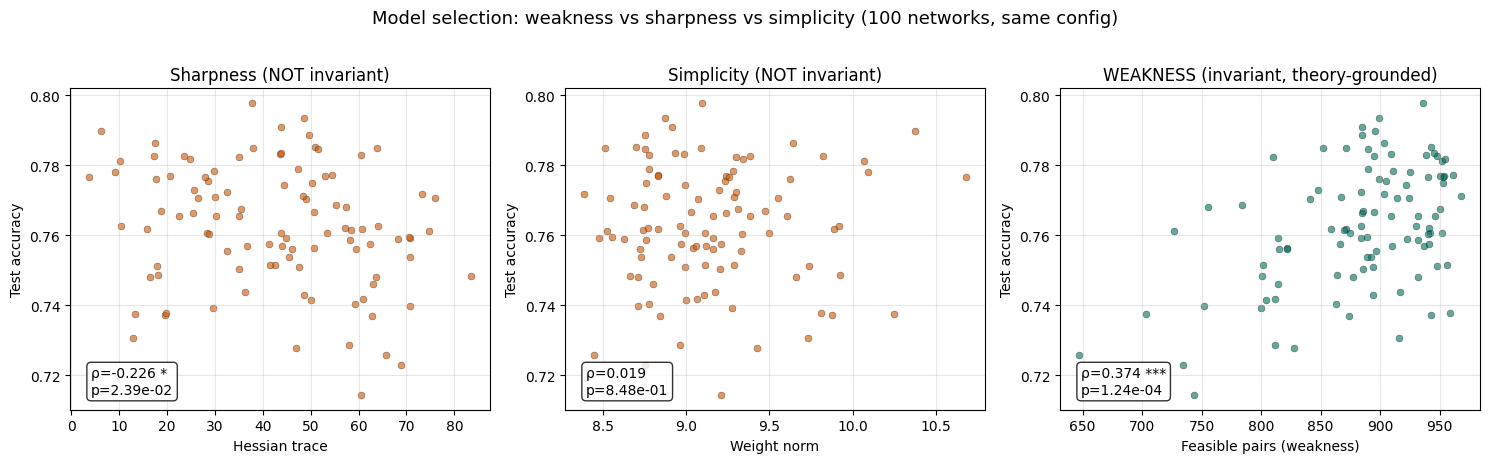

Saved fig_pairproxy


In [ ]:
######################################################################
# FIGURES
######################################################################
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

def plot_one(ax, x, y, xlabel, title, color):
    ax.scatter(x, y, s=25, alpha=0.6, c=color, edgecolors='k', lw=0.3)
    if len(set(x)) > 1:
        r, p = spearmanr(y, x)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        ax.text(0.05, 0.05, f'ρ={r:.3f} {sig}\np={p:.2e}',
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    ax.set(xlabel=xlabel, ylabel='Test accuracy', title=title)
    ax.grid(True, alpha=0.3)

plot_one(axes[0], ht, ta, 'Hessian trace',
         'Sharpness (NOT invariant)', '#CC5500')
plot_one(axes[1], wn, ta, 'Weight norm',
         'Simplicity (NOT invariant)', '#CC5500')
plot_one(axes[2], pp, ta, 'Feasible pairs (weakness)',
         'WEAKNESS (invariant, theory-grounded)', '#006D5B')

plt.suptitle(f'Model selection: weakness vs sharpness vs simplicity '
             f'({N_NETS} networks, same config)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_pairproxy.pdf', bbox_inches='tight', dpi=200)
plt.savefig('fig_pairproxy.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved fig_pairproxy')

In [ ]:
######################################################################
# SAVE AND DOWNLOAD
######################################################################
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, (np.integer,)): return int(obj)
        return super().default(obj)

save_nets = [{k:v for k,v in n.items() if k!='model'} for n in networks]
with open('pairproxy_results.json', 'w') as f:
    json.dump(save_nets, f, indent=2, cls=NpEncoder)

print(f'Total time: {(time.time()-t_global)/60:.1f} min')

from google.colab import files
for f in ['pairproxy_results.json', 'fig_pairproxy.pdf', 'fig_pairproxy.png']:
    try: files.download(f); print(f'Downloaded {f}')
    except Exception as e: print(f'Skip {f}: {e}')